<a href="https://colab.research.google.com/github/jsarroyo91-ops/Aprendizaje-Autom-tico/blob/main/Taller_Spam_AA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Calsificación de Mensajes SPAM mediante modelos Naive Bayes

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [2]:

#Carga de Archivo smap.csv

from google.colab import files
archivos_subidos = files.upload()

for nombre_archivo in archivos_subidos.keys():
    print(f'Archivo subido con éxito: {nombre_archivo}')


Saving spam.csv to spam.csv
Archivo subido con éxito: spam.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
df=pd.read_csv('spam.csv', encoding= 'latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
#lectura del dataset
# se selecciona las columnas necesrias v1 y v2 (categorias y texto)
df_spam_data=df[['v1','v2']]
df_spam_data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
#renombramientos de columnas
df_spam_data=df_spam_data.rename(
    columns={
        'v1':'categoria',
        'v2':'descripcion'
    }
    )
df_spam_data.head()

,categoria,descripcion
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
# Separación de variables de datos
X=df_spam_data['descripcion']
y=df_spam_data['categoria']

# División de dataset para entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=35)


In [40]:
# transformación de datos de texto en datos numéricos
# Crea una matriz en la que cada columna representa una palabra y cada fila un mensaje

vectorizador=CountVectorizer()
X_train_vec=vectorizador.fit_transform(X_train)
x_test_vec=vectorizador.transform(X_test)


In [8]:
# Modelo GaussianNB
# Modelo pensado para variabes numéricas continuas

model_gaussian=GaussianNB()
model_gaussian.fit(X_train_vec.toarray(),y_train)

GaussianNB()

In [9]:

y_predG = model_gaussian.predict(x_test_vec.toarray())
print(y_predG)

['ham' 'ham' 'ham' ... 'ham' 'ham' 'ham']


Calculo de métricias

In [10]:
print("Accuracy Gaussiano NB",
    accuracy_score(
        y_test,
        y_predG
    )
)

Accuracy Gaussiano NB 0.9061004784688995


In [11]:
print("F-1 Score Gaussiano NB: ", f1_score( y_test, y_predG, pos_label='spam'))

F-1 Score Gaussiano NB:  0.7211367673179396


In [41]:
print("Reporte de clasificación - Gaussiano NB:")
print(
    classification_report(
        y_test,
        y_predG,
        target_names=['ham', 'spam']
    )
)

Reporte de clasificación - Gaussiano NB:
              precision    recall  f1-score   support

         ham       0.98      0.91      0.94      1449
        spam       0.60      0.91      0.72       223

    accuracy                           0.91      1672
   macro avg       0.79      0.91      0.83      1672
weighted avg       0.93      0.91      0.91      1672



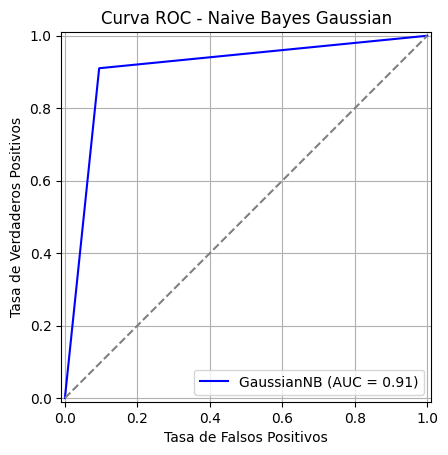

Matriz de confusión - Gaussian NB:
[[1312  137]
 [  20  203]]


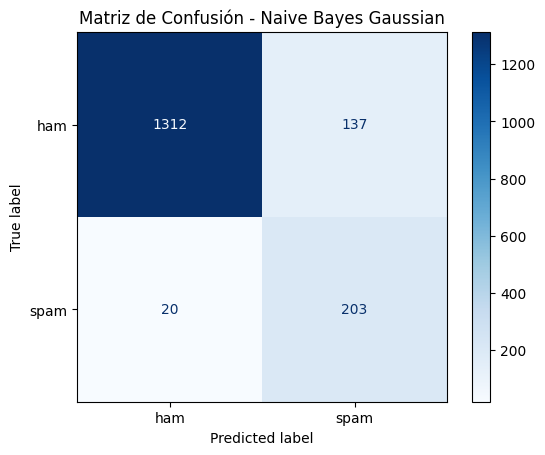

In [43]:
# Probabilidades necesarias para calcular AUC-ROC
y_probG = model_gaussian.predict_proba(x_test_vec.toarray())[:, 1]

#Curva ROC-AUC
RocCurveDisplay.from_predictions(
    y_test,
    y_probG,
    pos_label='spam',
    name="GaussianNB",
    color="blue"
)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("Curva ROC - Naive Bayes Gaussian")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.grid()
plt.show()

# MATRIZ DE CONFUSIÓN

target_names = ['ham', 'spam']
matriz_Gaussian = confusion_matrix(
    y_test,
    y_predG
)

print("Matriz de confusión - Gaussian NB:")
print(matriz_Gaussian)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_Gaussian,
    display_labels=target_names
)

disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Naive Bayes Gaussian")
plt.show()

En el modelo GaussianNB, la curva AUC-ROC permite observar qué tan bien el clasificador separa los mensajes ham de los mensajes spam usando las probabilidades estimadas por el modelo. Si la curva se aleja de la línea diagonal y se acerca a la esquina superior izquierda, significa que el modelo tiene capacidad para distinguir entre ambas clases. Sin embargo, como GaussianNB no es el modelo más adecuado para datos de conteo de palabras, su rendimiento puede ser menor en comparación con MultinomialNB. La matriz de confusión permite identificar cuántos mensajes ham y spam fueron clasificados correctamente, así como los falsos positivos y falsos negativos. En este contexto, un falso negativo ocurre cuando un mensaje spam se clasifica como ham, lo cual es importante porque implica que un correo no deseado no fue detectado por el sistema.

In [44]:
#MultinomialNB
# Este modelo trabaja con datos de conteo como frecuencias de palabras (CountVectorizer)

model_multinomial=MultinomialNB()

model_multinomial.fit(X_train_vec,y_train)

y_predM=model_multinomial.predict(x_test_vec)

print(y_predM)

['ham' 'ham' 'ham' ... 'ham' 'ham' 'ham']


In [46]:
#Métricas

print("\nAccuracy Multinomial NB",
    accuracy_score(
        y_test,
        y_predM
    )
)
print("\nF-1 Score Multinomial NB: ", f1_score( y_test, y_predM, pos_label='spam'))

print("\nReporte de clasificación - Multinomial NB:")
print(
    classification_report(
        y_test,
        y_predM,
        target_names=['ham', 'spam']
    )
)


Accuracy Multinomial NB 0.9850478468899522

F-1 Score Multinomial NB:  0.9425287356321839

Reporte de clasificación - Multinomial NB:
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99      1449
        spam       0.97      0.92      0.94       223

    accuracy                           0.99      1672
   macro avg       0.98      0.96      0.97      1672
weighted avg       0.98      0.99      0.98      1672



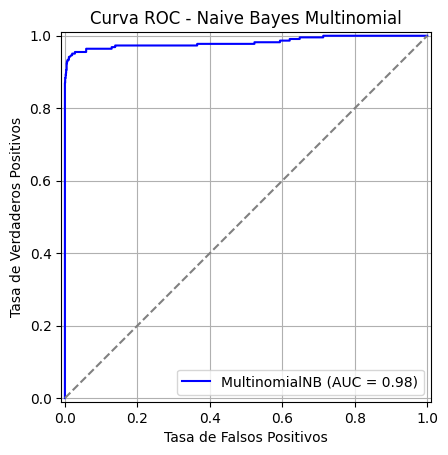

Matriz de confusión - Multinomial NB:
[[1442    7]
 [  18  205]]


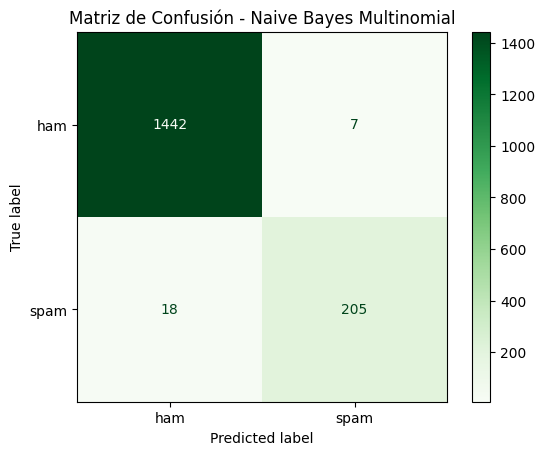

In [47]:
# Probabilidades necesarias para calcular AUC-ROC
y_probM = model_multinomial.predict_proba(x_test_vec.toarray())[:, 1]

#Curva ROC-AUC
RocCurveDisplay.from_predictions(
    y_test,
    y_probM,
    pos_label='spam',
    name="MultinomialNB",
    color="blue"
)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("Curva ROC - Naive Bayes Multinomial")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.grid()
plt.show()

# MATRIZ DE CONFUSIÓN

target_names = ['ham', 'spam']
matriz_multinomial = confusion_matrix(
    y_test,
    y_predM
)

print("Matriz de confusión - Multinomial NB:")
print(matriz_multinomial)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_multinomial,
    display_labels=target_names
)

disp.plot(cmap="Greens")
plt.title("Matriz de Confusión - Naive Bayes Multinomial")
plt.show()

En el modelo MultinomialNB, la curva AUC-ROC suele representar mejor la separación entre ham y spam, porque este modelo está diseñado para trabajar con conteos de palabras. Si el AUC-ROC es alto, significa que el modelo asigna mayores probabilidades de spam a los mensajes que realmente son spam y menores probabilidades a los mensajes normales. La matriz de confusión permite confirmar esta capacidad observando la cantidad de aciertos y errores por clase. Si la diagonal principal contiene la mayoría de los casos, el modelo está clasificando correctamente la mayoría de mensajes. En este problema, el modelo multinomial suele ser más apropiado porque aprende patrones de frecuencia de palabras. Por ello, si presenta menos falsos negativos y falsos positivos que GaussianNB, se puede concluir que es el modelo más adecuado para la clasificación de spam en este dataset.